In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style ="whitegrid")


In [5]:
df = pd.read_csv("../data/raw/credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [64]:
target = "loan_status"
df[target].value_counts(normalize=True)

loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

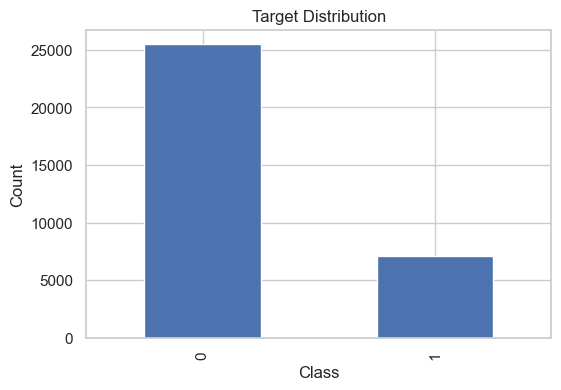

In [10]:
plt.figure(figsize=(6,4))
df[target].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


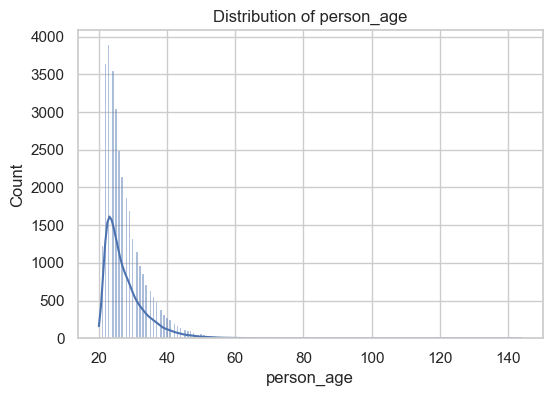

In [65]:
plt.figure(figsize=(6,4))
sns.histplot(df["person_age"], kde=True)
plt.title("Distribution of person_age")
plt.show()


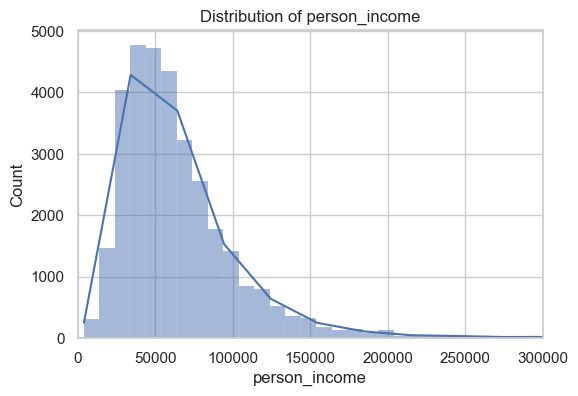

In [59]:
plt.figure(figsize=(6,4))
sns.histplot(df["person_income"], kde=True, binwidth = 10000)
# plt.xscale("log")
plt.xlim(0,300000)
plt.title("Distribution of person_income")
plt.show()


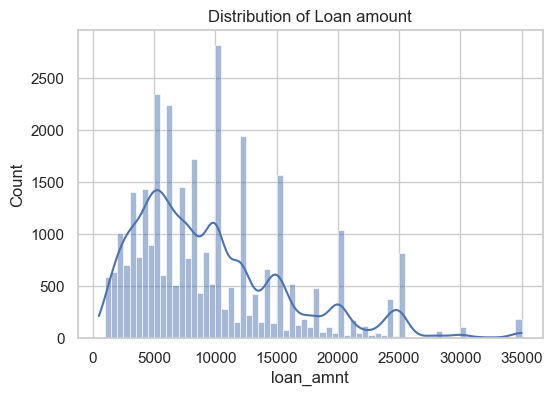

In [62]:
plt.figure(figsize=(6,4))
sns.histplot(df["loan_amnt"], kde=True, binwidth=500)
plt.title(f"Distribution of Loan amount")
plt.show()


(0.0, 250000.0)

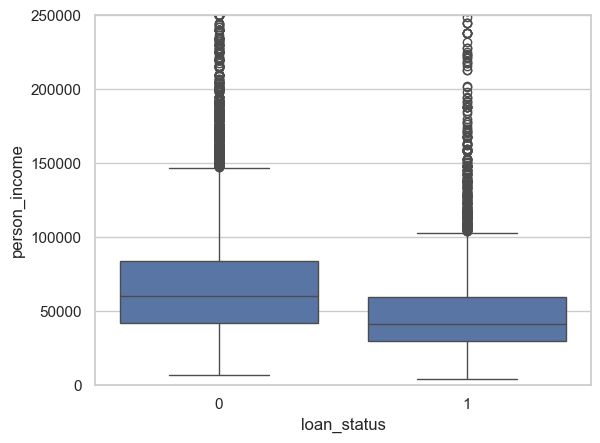

In [63]:
sns.boxplot(x="loan_status", y="person_income", data=df)
plt.ylim(0,250000)

In [70]:
df.isnull().sum()


person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

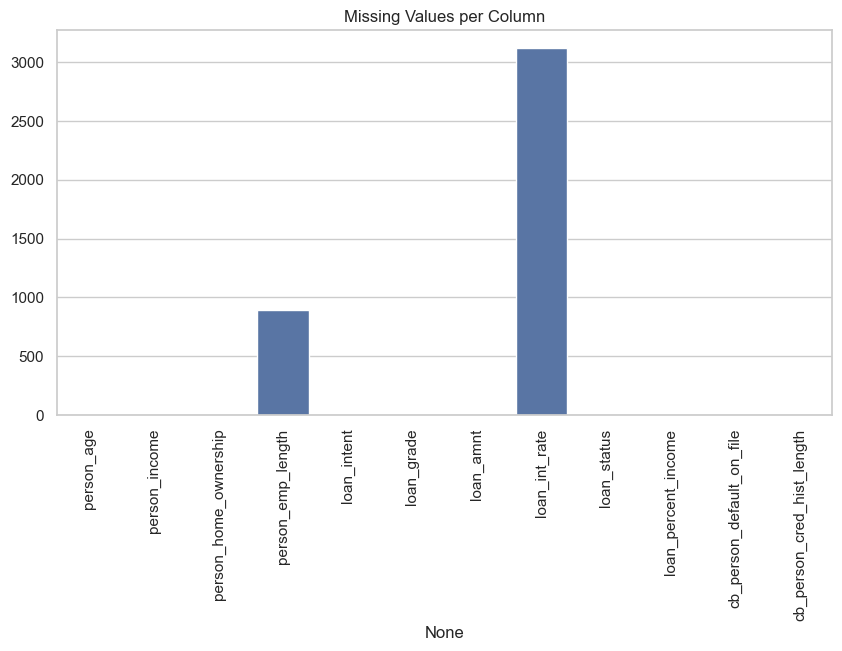

In [71]:
plt.figure(figsize=(10,5))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values)
plt.xticks(rotation=90)
plt.title("Missing Values per Column")
plt.show()

### EDA SUMMERY

- Dataset has XXXXX rows and XX columns.
- Target variable = default
- Class distribution: X% default, Y% non-default (imbalanced / balanced)
- Key numerical variables explored: age, income, loan_amount
- Missing values exist in columns: ______
- Next step: Data Cleaning & Feature Engineering

Most loan applicants fall in the mid-income range.
There are very few extremely low-income borrowers.
Income distribution is right-skewed, but when zoomed
to 0–20K range, majority concentration is above 10K.
This indicates loans are mostly taken by stable-income
individuals, which is realistic.


Loan amounts are highly bucketed rather than continuous. 
There are strong spikes at values such as 5,000, 7,500, 
10,000, 15,000 etc. This indicates standardized loan 
products offered by the lender instead of arbitrary amounts.

This insight is valuable because:
- Feature engineering may benefit from bucketing loan amounts
- These buckets may correlate differently with default risk
- It helps understand product design and business constraints



There is a clear difference in income distribution between 
borrowers who default and those who do not.

Borrowers who default (loan_status = 1) generally have lower 
median income and lower overall earning range compared to 
non-defaulters. This indicates that income is an important 
predictor of repayment ability.

However, there are also high-income defaulters, meaning that 
income alone does not fully explain default behavior.


df.groupby("loan_status")["person_income"].median()
sns.kdeplot(data=df, x="person_income", hue="loan_status", common_norm=False)
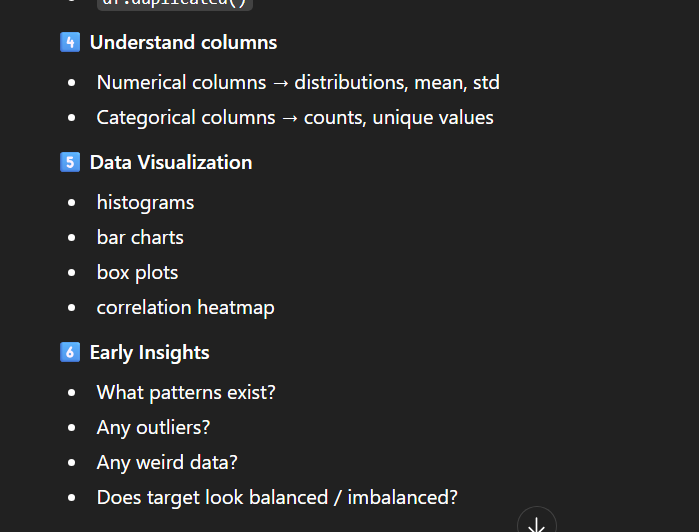
